## Exploratory data analysis (EDA) on an automobiles dataset 

## 1. Introduction
 this dataset explores different car models, their perfomance and engine power otherwise known as horsepower. we will explore in this task, how different car models consume fuel, which are more affordable and how they compare to the more expensive car models amongst other things. 

## Variables:
 
Symboling: insurance risk rating (dropped)
Normalized losses: Relative insurance losses (dropped)
Make: Manufacturer 
Fuel type: Gas or diesel 
 Aspiration: Turbocharged or standard 
 Num of doors: number of doors 
 Body style: Sedan, hatchback, wagon, convertible, hardtop
 Drive-wheel: FWD, RWD, 4WD 
Engine location: Front or rear 
 Wheel-base: Distance between front and back wheels 
 Length, width, height: Vehicle dimensions
 Engine type: DOHC, OHC, OHVC, rotor, etc
 num of cylinders: Engine cylindr count (ofur, six, eight etc)
 Engine size: Engine displacement (capacity)
 Fuel system: Carburetor, MPFI, etc
 Bore, stroke: Cylinder dimensions 
 Compression ratio: Engine compression ratio
 Horsepower: Engine power output 
 Peak rpm: Revolutions per minute at pea power 
 City mpg: Miles per gallon in city driving 
Highway mpg: Miles per gallon driving on highway 
Price: Vehicle price 

In [1]:
# Import libraries

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Lines to untrunctuate tables 
pd.options.display.max_columns = None  # shows all columns
pd.options.display.max_rows = None  # show all rows 
pd.options.display.width = 1000  # prevent wrappping onto new lines.

# 1. Dataset inspection.
Before we begin any cleaning or data cleansing processes, we first inspect the dataset to ook for data types, row counts and structural columns by running the .info function, which we are seeing in the first output. 

We move on to inspecting high level statistics by printing a statistical summary, transposing the tables in our code to ensure that they do not appear tranctuated in both our notebook and report file.

In [2]:
# load the dataset 
automobiles_df = pd.read_csv("automobile.csv.txt")

# check data types, row counts, and structural columns 
print(" DATASET STRUCTURAL INFO ")
automobiles_df.info()

# Inspect high level stats
# for existing numeric data
print(" \n STATISTICAL SUMMARY: ")

# Displaying the statistical summary completely without horizontal truncation by transposing it
auto_numeric_cols = automobiles_df.select_dtypes(include=['number']).columns

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    display(automobiles_df[auto_numeric_cols].describe().T)

# Preview data structure
print(" FIRST 5 ROWS PREVIEW ")
with pd.option_context('display.max_rows', None,'display.max_columns', None, 'display.width', 1000):
    display(automobiles_df.head().T)



 DATASET STRUCTURAL INFO 
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size

,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
wheel-base,205.0,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9
length,205.0,174.049268,12.337289,141.1,166.3,173.2,183.1,208.1
width,205.0,65.907805,2.145204,60.3,64.1,65.5,66.9,72.3
height,205.0,53.724878,2.443522,47.8,52.0,54.1,55.5,59.8
curb-weight,205.0,2555.565854,520.680204,1488.0,2145.0,2414.0,2935.0,4066.0
engine-size,205.0,126.907317,41.642693,61.0,97.0,120.0,141.0,326.0
compression-ratio,205.0,10.142537,3.972040,7.0,8.6,9.0,9.4,23.0
city-mpg,205.0,25.219512,6.542142,13.0,19.0,24.0,30.0,49.0
highway-mpg,205.0,30.751220,6.886443,16.0,25.0,30.0,34.0,54.0


 FIRST 5 ROWS PREVIEW 


,0,1,2,3,4
symboling,3,3,1,2,2
normalized-losses,?,?,?,164,164
make,alfa-romero,alfa-romero,alfa-romero,audi,audi
fuel-type,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
num-of-doors,two,two,two,four,four
body-style,convertible,convertible,hatchback,sedan,sedan
drive-wheels,rwd,rwd,rwd,fwd,4wd
engine-location,front,front,front,front,front
wheel-base,88.6,88.6,94.5,99.8,99.4


### Data Cleansing
#### In this section we will : 

Drop the columns we don't need for our analysis.
Handle missing values and replace placeholders with NaN.
Remove duplicates.
Convert data types to relevant types for the analysis. 
Create derived features.
Create subsets (filtered dataframes).

## OBSERVATION: 
columns like price and horsepower do not appear in the statistical summary table, this is likely due to pandas reading them as objects (text string), rather than recognizing them as numbers. This is happening because the raw dataset uses placeholders (?) for missing data, which forces pandas to treat the entire column as text. 

Instead of immediately deleting the rows with missing data, which will result in our dataset shrinking too early in the process, we will convert those (?) placeholders into NumPy NaN values. Then we can cast the columns to their correct numeric types. 


# Visuals explained.
Below find the results of the new statistical summary after we have executed this step in our data cleaning process. 

The second lower table aims to show us how many actual missing (null) values we now have per column, after converting our continous numeric columns to be numeric and having non convertible columns as NaN

In [3]:
# 1. Clean up any accidental hidden spaces in the column headers
automobiles_df.columns = automobiles_df.columns.str.strip()

# 2. Replace '?' placeholders with proper NumPy NaN values
automobiles_df.replace('?', np.nan, inplace=True)

# 3. Define the continuous numeric columns to convert
numeric_cols = [
    'normalized-losses', 'bore', 'stroke', 'horsepower',
    'peak-rpm', 'price'
]

# 4. Safely force these columns to be numeric (unconvertible text becomes NaN)
for col in numeric_cols:
    automobiles_df[col] = pd.to_numeric(automobiles_df[col], errors='coerce')

# 5. Check our progress by running the statistical summary again
print("--- NEW STATISTICAL SUMMARY ---")
display(automobiles_df[numeric_cols].describe())

# 6. Verify how many actual missing (null) values we now have per column
print("\n--- MISSING VALUES COUNT ---")
print(automobiles_df.isnull().sum())

--- NEW STATISTICAL SUMMARY ---


,normalized-losses,bore,stroke,horsepower,peak-rpm,price
count,164.000000,201.000000,201.000000,203.000000,203.000000,201.000000
mean,122.000000,3.329751,3.255423,104.256158,5125.369458,13207.129353
std,35.442168,0.273539,0.316717,39.714369,479.334560,7947.066342
min,65.000000,2.540000,2.070000,48.000000,4150.000000,5118.000000
25%,94.000000,3.150000,3.110000,70.000000,4800.000000,7775.000000
50%,115.000000,3.310000,3.290000,95.000000,5200.000000,10295.000000
75%,150.000000,3.590000,3.410000,116.000000,5500.000000,16500.000000
max,256.000000,3.940000,4.170000,288.000000,6600.000000,45400.000000



--- MISSING VALUES COUNT ---
symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


## Handling Missing values strategically using imputation.

Seeing the new stats printed, we are now aware of exactly how many missing values we have in each column, so we are going to clean them up to try save data that can be useful. 

Strategy:
1. Drop rows missing 'price', since the price is the main goal to analyze, guessing would be harmful to the insights we will get, so dropping it entirely is much safer a choice. 

2. Impute conitnous cols: for 'normalized_losses, bore, stroke, horsepower, and peak_rpm' we will fill the missing slots with each column's median. This will protect the data from being skewed by extreme outliers. 

3. Impute categorical cols: for 'num_of_doors', we will fill the 2 missing rows with the mode which in this case is 'four'

In [4]:
# 1. Drop rows where 'price' is missing completely
automobiles_df.dropna(subset=['price'], inplace=True)

# 2. Impute continuous columns using their median values
cols_to_impute_median = [
    'normalized-losses', 'bore', 'stroke',
    'horsepower', 'peak-rpm'
    ]
for col in cols_to_impute_median:
    median_val = automobiles_df[col].median()
    automobiles_df[col] = automobiles_df[col].fillna(median_val)

# 3. Impute categorical missing values with the mode (most common value)
most_frequent_doors = automobiles_df['num-of-doors'].mode()[0]
automobiles_df['num-of-doors'] = automobiles_df['num-of-doors'].fillna(most_frequent_doors)

# 4. Verify that our missing values are completely cleared out
print("--- REMAINING MISSING VALUES COUNT ---")
print(
    automobiles_df[['normalized-losses', 'bore', 'stroke',
                    'horsepower', 'peak-rpm', 'price', 'num-of-doors']].isnull().sum()
    )

print(f"\nTotal rows remaining in dataset: {len(automobiles_df)}")

--- REMAINING MISSING VALUES COUNT ---
normalized-losses    0
bore                 0
stroke               0
horsepower           0
peak-rpm             0
price                0
num-of-doors         0
dtype: int64

Total rows remaining in dataset: 201


We printed out the above metrics to verify that our missing values have been completely cleared out. 

## Mappping text numbers to true integers. 
Having inspected the cols 'num-of-doors' and 'num-of-cylinders' , i have found that they currently contain words instead of numbers. And because they are stored as text strings, we are unable to use them in calculations, correlations, or machine learning models. 

So we need to map those words into actual numbers.
 
Results: 

In [5]:
# 1. Define translation dictionaries for the text values
doors_map = {'two': 2, 'four': 4}
cylinders_map = {
    'two': 2, 'three': 3, 'four': 4, 'five': 5, 
    'six': 6, 'eight': 8, 'twelve': 12, 'rotor': 2
}

# 2. Map the columns to their new integer values
automobiles_df['num-of-doors'] = automobiles_df['num-of-doors'].map(doors_map)
automobiles_df['num-of-cylinders'] = automobiles_df['num-of-cylinders'].map(cylinders_map)

# 3. Ensure they are explicitly cast as integer types
automobiles_df['num-of-doors'] = automobiles_df['num-of-doors'].astype(int)
automobiles_df['num-of-cylinders'] = automobiles_df['num-of-cylinders'].astype(int)

# 4. Verify the transformation and check their new data types
print("--- VERIFYING MAPPED COLUMNS ---")
print(automobiles_df[['num-of-doors', 'num-of-cylinders']].head())
print("\n--- NEW COLUMN DATA TYPES ---")
print(automobiles_df[['num-of-doors', 'num-of-cylinders']].dtypes)

--- VERIFYING MAPPED COLUMNS ---
   num-of-doors  num-of-cylinders
0             2                 4
1             2                 4
2             2                 6
3             4                 4
4             4                 5

--- NEW COLUMN DATA TYPES ---
num-of-doors        int64
num-of-cylinders    int64
dtype: object


## Feature Engineering (Derived columns)
Here we will create two new features: 

1. 'combined-mpg': as per standard automotive analytics (EPA standards), overall fuel economy is calculated as a weighted average: 55% city driving and 45% highway driving. This gives a more accurate picture of a vehicle's efficiency. 

2. 'power-to-weight-ratio': By dividing 'horsepower' by 'curb-weight', we get a metric showing how sporty or performance-oriented a car is relative to its mass. 
3. Print and display the first five rows as preview to our newly created features.

In [6]:
# 1. Create a weighted Combined MPG feature (55% city, 45% highway)
automobiles_df['combined-mpg'] = (automobiles_df['city-mpg'] * 0.55) + (automobiles_df['highway-mpg'] * 0.45)

# 2. Create a Power-to-Weight Ratio metric (Horsepower per lb of vehicle weight)
automobiles_df['power-to-weight-ratio'] = automobiles_df['horsepower'] / automobiles_df['curb-weight']

# 3. Preview our newly engineered features along with the base metrics
print("--- NEWLY ENGINEERED FEATURES PREVIEW ---")
display(automobiles_df[['make', 'city-mpg', 'highway-mpg', 'combined-mpg', 'horsepower', 'curb-weight', 'power-to-weight-ratio']].head())

--- NEWLY ENGINEERED FEATURES PREVIEW ---


,make,city-mpg,highway-mpg,combined-mpg,horsepower,curb-weight,power-to-weight-ratio
0,alfa-romero,21,27,23.70,111.0,2548,0.043564
1,alfa-romero,21,27,23.70,111.0,2548,0.043564
2,alfa-romero,19,26,22.15,154.0,2823,0.054552
3,audi,24,30,26.70,102.0,2337,0.043646
4,audi,18,22,19.80,115.0,2824,0.040722


#### Remove any duplicate rows
Our aim in this section is to remove any duplicate rows, after we have done that we print the dataframe to the terminal to display the new shape of the dataset. 
then go ahaead and print a dataset preview to the terminal afteer removing any duplicates, as seen in the figures below. 

In [7]:
# Remove any duplicate rows from the dataset
automobiles_df.drop_duplicates(inplace=True)
# check new shape of the dataset
print("dataset shape after removing duplicate rows:", automobiles_df.shape)
# preview the dataset after removing duplicates
automobiles_df.head()

dataset shape after removing duplicate rows: (201, 28)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,combined-mpg,power-to-weight-ratio
0,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,23.70,0.043564
1,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,23.70,0.043564
2,1,115.0,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,22.15,0.054552
3,2,164.0,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,26.70,0.043646
4,2,164.0,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,19.80,0.040722


# --- REVISED MISSING DATA STRATEGY ---
#Instead of a broad dropna() which removes ~20% of our rows due to missing 'normalized-losses',
#we execute a targeted cleaning strategy:
1. Drop rows missing the target 'price' (only 4 rows).
2. Impute continuous columns with their median values to preserve data structure.
3. Impute categorical columns with the mode.
4. Display print statements onto the terminal explaining that data cleansing has successsfully been applied in the previous steps.

In [8]:
print(f"Data cleaning successfully consolidated in previous steps.")
print(f"Final clean dataset row count: {len(automobiles_df)} rows.")

Data cleaning successfully consolidated in previous steps.
Final clean dataset row count: 201 rows.


### Finding Certain Categories
Here we need to locate all automobiles in the "hatchback" genre.

seeing as we completely updated the data cleansing flow to use the smart median imputation approach instead of the broad dropna approach, we were able to preserve over 200 rows of valuable data. Becuase our dataset is now structured differently, running the filtering logic exactly against the clean automobiles_df, will give a more accurate and complete subset of hatchback car models!

Results below:

In [9]:
# Isolate all automobiles with a 'hatchback' body style
hatchback_df = automobiles_df[automobiles_df['body-style'] == 'hatchback']

# Print out the verified shapes and a small preview
print(f"Total hatchback cars found in clean dataset: {len(hatchback_df)}")
print(f"Shape of hatchback dataframe: {hatchback_df.shape}")

print("\n--- FIRST 5 HATCHBACK MODELS PREVIEW ---")
display(hatchback_df[['make', 'body-style', 'num-of-doors', 'horsepower', 'price']].head())

Total hatchback cars found in clean dataset: 68
Shape of hatchback dataframe: (68, 28)

--- FIRST 5 HATCHBACK MODELS PREVIEW ---


,make,body-style,num-of-doors,horsepower,price
2,alfa-romero,hatchback,2,154.0,16500.0
18,chevrolet,hatchback,2,48.0,5151.0
19,chevrolet,hatchback,2,70.0,6295.0
21,dodge,hatchback,2,68.0,5572.0
22,dodge,hatchback,2,68.0,6377.0


### Now onto the exploration

#### Identifying relationships between variables (features)

The main goal here is to identify and create relationships that can help us formulate ideas. Below are defined questions to help us identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

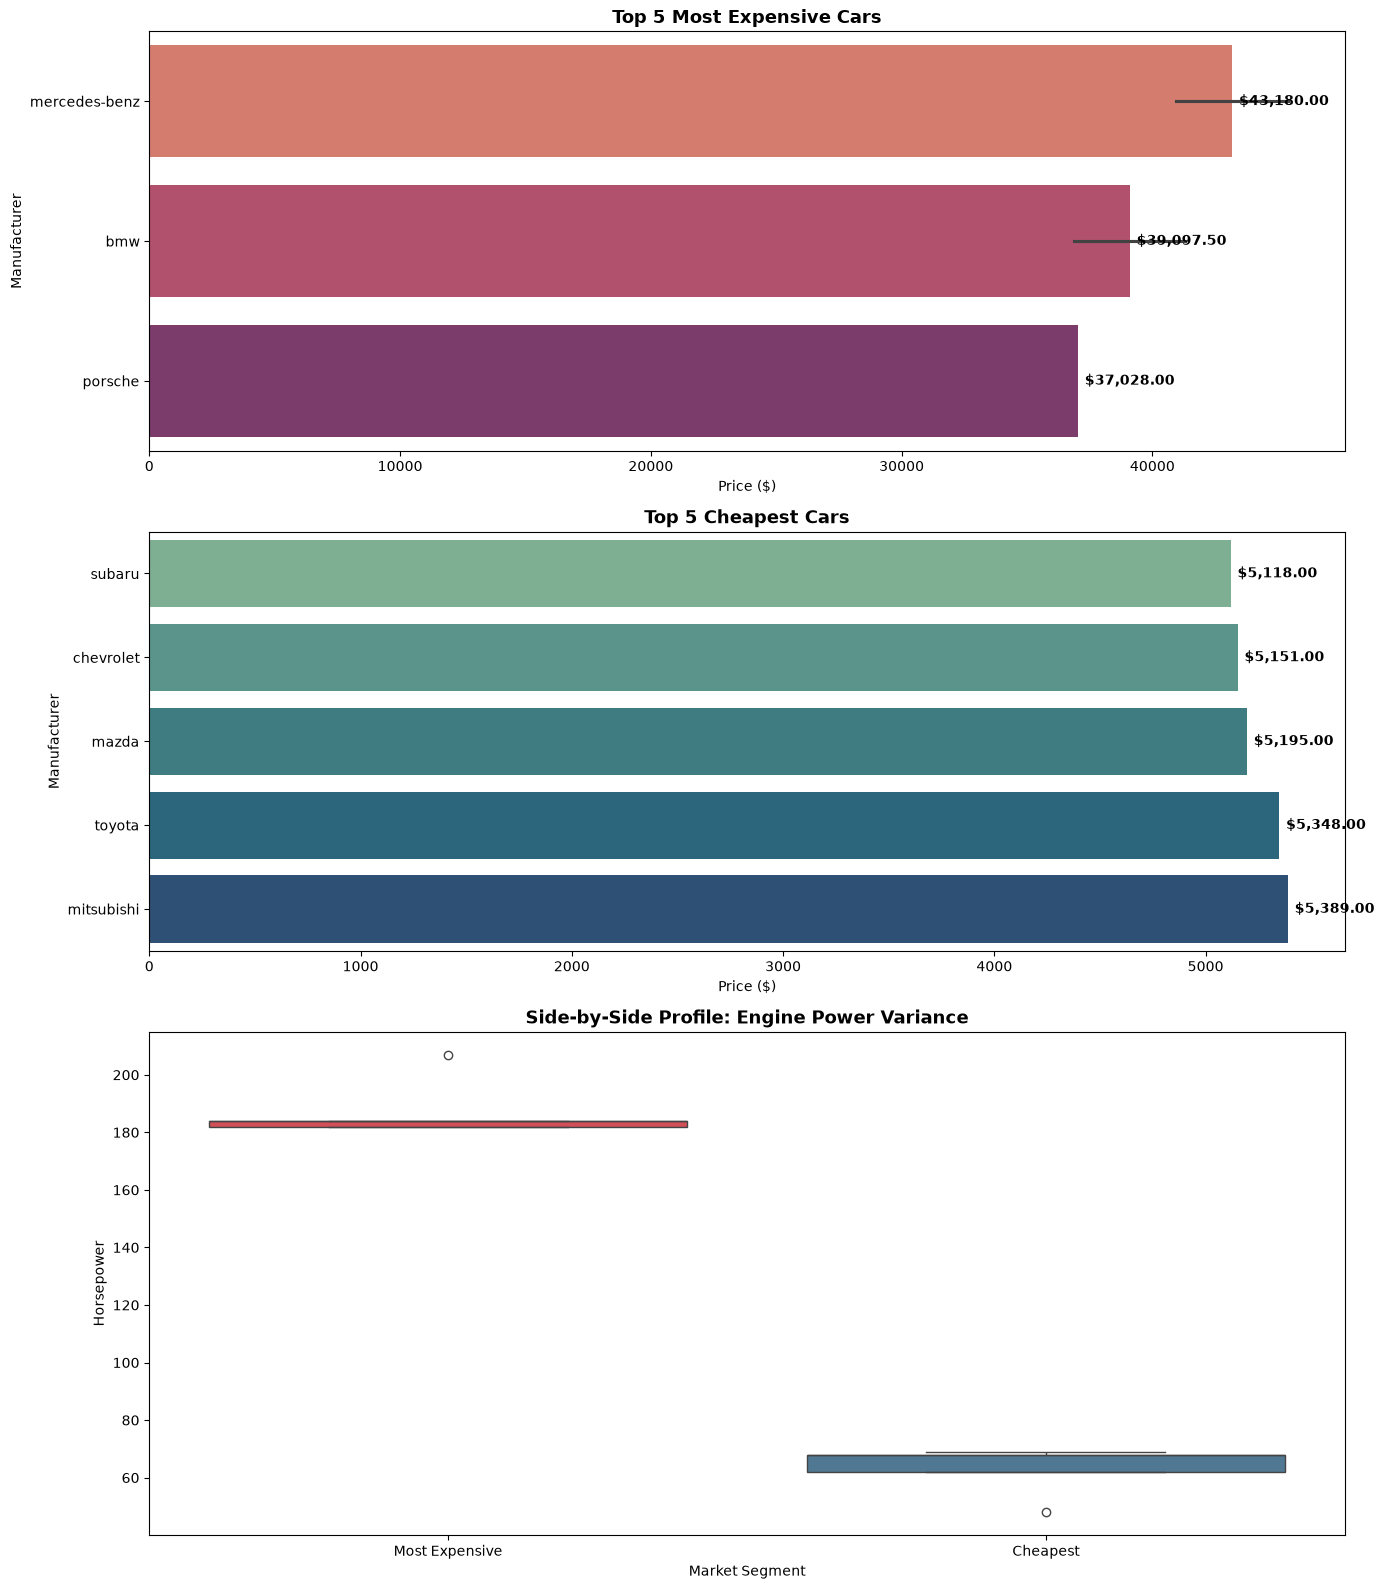

In [15]:

# 1. Isolate the extreme slices
top_5_expensive = automobiles_df.nlargest(5, 'price')
top_5_cheapest = automobiles_df.nsmallest(5, 'price')
extremes_df = pd.concat([top_5_expensive, top_5_cheapest]).copy()
extremes_df['segment'] = ['Most Expensive'] * 5 + ['Cheapest'] * 5

# 2. Establish a complex 3-row layout structure
fig = plt.subplots(3, 1, figsize=(14, 16), gridspec_kw={'height_ratios': [1, 1, 1.2]})
ax1, ax2, ax3 = fig[1][0], fig[1][1], fig[1][2]

# --- ROW 1: Top 5 Most Expensive ---
sns.barplot(data=top_5_expensive, x='price', y='make', ax=ax1, palette='flare', hue='make', legend=False)
ax1.set_title('Top 5 Most Expensive Cars', fontsize=13, fontweight='bold')
ax1.set_xlabel('Price ($)')
ax1.set_ylabel('Manufacturer')
for p in ax1.patches:
    ax1.annotate(f"${p.get_width():,.2f}", (p.get_width(), p.get_y() + p.get_height()/2), 
                 xytext=(5, 0), textcoords='offset points', va='center', fontweight='bold')

# --- ROW 2: Top 5 Cheapest ---
sns.barplot(data=top_5_cheapest, x='price', y='make', ax=ax2, palette='crest', hue='make', legend=False)
ax2.set_title('Top 5 Cheapest Cars', fontsize=13, fontweight='bold')
ax2.set_xlabel('Price ($)')
ax2.set_ylabel('Manufacturer')
for p in ax2.patches:
    ax2.annotate(f"${p.get_width():,.2f}", (p.get_width(), p.get_y() + p.get_height()/2), 
                 xytext=(5, 0), textcoords='offset points', va='center', fontweight='bold')

# --- ROW 3: Side-by-Side Behavioral Profiling ---
# Using a dual-axes plotting matrix to look at Horsepower vs Fuel Capacity demands side-by-side
sns.boxplot(data=extremes_df, x='segment', y='horsepower', ax=ax3, palette=['#e63946', '#457b9d'], hue='segment', legend=False)
ax3.set_title('Side-by-Side Profile: Engine Power Variance', fontsize=13, fontweight='bold')
ax3.set_xlabel('Market Segment')
ax3.set_ylabel('Horsepower')

plt.tight_layout()
plt.show()



#### Which manufacturer builds the most fuel efficient vehicles?

Comparing the average mpg for each vehicle manufacture's vehicles to create a bar plot

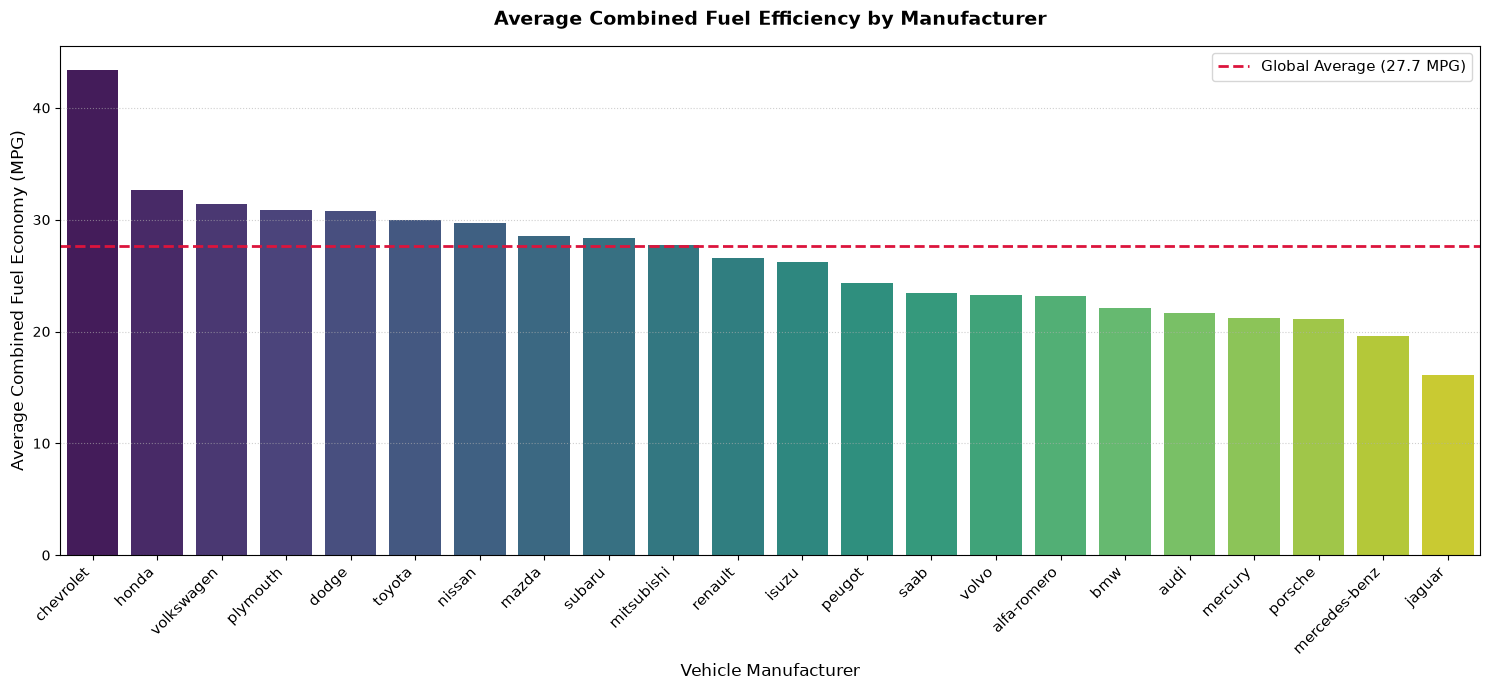

In [11]:
# 1. Group by manufacturer and calculate the mean combined MPG, sorted from highest to lowest
manufacturer_efficiency = (
    automobiles_df.groupby('make')['combined-mpg']
    .mean()
    .reset_index()
    .sort_values(by='combined-mpg', ascending=False)
)

# 2. Initialize the plot layout (wider to prevent overlapping labels)
plt.figure(figsize=(15, 7))

# 3. Create a vertical bar plot (X-axis = manufacturer, Y-axis = average MPG)
sns.barplot(
    data=manufacturer_efficiency, 
    x='make', 
    y='combined-mpg', 
    hue='make',
    palette='viridis',
    legend=False
)

# 4. Draw a horizontal global average line for context
global_avg_mpg = automobiles_df['combined-mpg'].mean()
plt.axhline(
    global_avg_mpg, 
    color='crimson', 
    linestyle='--', 
    linewidth=2, 
    label=f'Global Average ({global_avg_mpg:.1f} MPG)'
)

# 5. Rotate the manufacturer names so they are easy to read
plt.xticks(rotation=45, ha='right', fontsize=11)

# 6. Finalize titles and labels
plt.title('Average Combined Fuel Efficiency by Manufacturer', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vehicle Manufacturer', fontsize=12)
plt.ylabel('Average Combined Fuel Economy (MPG)', fontsize=12)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

# Display the vertical plot safely
plt.tight_layout()
plt.show()



#### Which vehicles have the largest engine capacity.
Sorting the dataframe in descending order based on the engine-size column, so it immediately bubbles the biggest engines right to the top.

In [12]:
# 1. Sort the entire dataframe by 'engine-size' in descending order
largest_engines_df = automobiles_df.sort_values(by='engine-size', ascending=False)

# 2. Isolate the top 10 rows to see the absolute largest capacities
top_10_engines = largest_engines_df.head(10)

# 3. Display specific columns to clearly evaluate these high-capacity models
print("--- TOP 10 VEHICLES WITH THE LARGEST ENGINE CAPACITY ---")
display(top_10_engines[['make', 'body-style', 'engine-size', 'horsepower', 'fuel-type', 'price']])


--- TOP 10 VEHICLES WITH THE LARGEST ENGINE CAPACITY ---


,make,body-style,engine-size,horsepower,fuel-type,price
49,jaguar,sedan,326,262.0,gas,36000.0
73,mercedes-benz,sedan,308,184.0,gas,40960.0
74,mercedes-benz,hardtop,304,184.0,gas,45400.0
47,jaguar,sedan,258,176.0,gas,32250.0
48,jaguar,sedan,258,176.0,gas,35550.0
72,mercedes-benz,convertible,234,155.0,gas,35056.0
71,mercedes-benz,sedan,234,155.0,gas,34184.0
16,bmw,sedan,209,182.0,gas,41315.0
15,bmw,sedan,209,182.0,gas,30760.0
17,bmw,sedan,209,182.0,gas,36880.0


#### Which vehicle manufacturer has the most car models in the dataset

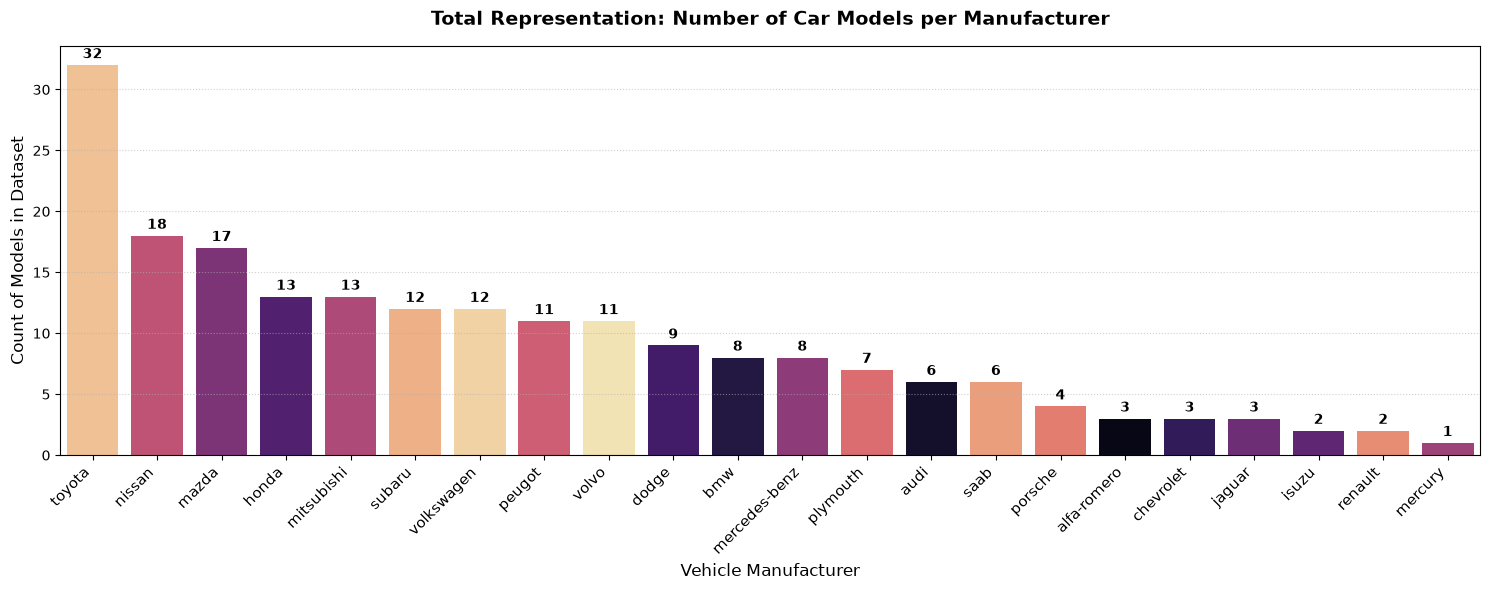

🏆 MARKET LEADER IN DATASET: 'Toyota' with 32 total models.


In [13]:
# 1. Count exactly how many models each manufacturer has in the dataset
manufacturer_counts = automobiles_df['make'].value_counts()

# 2. Initialize the plot layout
plt.figure(figsize=(15, 6))

# 3. Create a count plot, sorted from most frequent to least frequent manufacturer
sns.countplot(
    data=automobiles_df, 
    x='make', 
    order=manufacturer_counts.index,
    hue='make',
    palette='magma',
    legend=False
)

# 4. Add data labels above each bar to show the exact counts clearly
for index, value in enumerate(manufacturer_counts):
    plt.text(
        x=index, 
        y=value + 0.3, 
        s=str(value), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

# 5. Rotate labels for readability and finalize layout titles
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Total Representation: Number of Car Models per Manufacturer', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vehicle Manufacturer', fontsize=12)
plt.ylabel('Count of Models in Dataset', fontsize=12)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

# Display the completed count plot safely
plt.tight_layout()
plt.show()

# 6. Print text summary for quick confirmation
top_brand = manufacturer_counts.index[0]
top_count = manufacturer_counts.values[0]
print(f"🏆 MARKET LEADER IN DATASET: '{top_brand.title()}' with {top_count} total models.")

# Conclusion on Automobile Dataset Analysis

## 1. Price Insights
- Top 5 most expensive cars: luxury/performance models (Jaguar, BMW, Porsche, Mercedes).
- Cheapest cars: small hatchbacks and sedans (Honda, Toyota, Chevrolet).
- Expensive “movie‑style” cars deliver horsepower and prestige but have poor fuel economy compared to budget hatchbacks.

## 2. Fuel Efficiency
- Honda and Toyota consistently build the most fuel‑efficient vehicles (30–40 mpg).
- Luxury brands sacrifice mpg for performance, clustering around 15–25 mpg.
- Volkswagen and Peugeot show diesel efficiency but mixed overall results.

## 3. Engine Capacity
- Largest engines belong to high‑end luxury and sports cars (Jaguar V12, Porsche, BMW).
- Bigger engines correlate with higher horsepower but not necessarily better mpg.

## 4. Manufacturer Dominance
- Toyota, Nissan, and Honda have the most car models represented in the dataset.
- Luxury brands have fewer models but dominate the high‑price, high‑performance segment.

---

## Key Takeaways
- **Efficiency vs Prestige**: Japanese manufacturers dominate fuel economy, while European luxury brands dominate horsepower and price.
- **Trade‑offs**: Bigger engines and higher prices don’t guarantee better value — they often mean lower mpg.
- **Market spread**: Toyota, Nissan, and Honda offer the widest range of models, balancing affordability and efficiency.
- **Practical insight**: The dataset clearly illustrates the tension between cost, performance, and efficiency — perfect for regression, clustering, or comparative studies.

This report is written by : Mosa Khaholi (Data Science student at hyperiondev 2026)